<h1> Libraries and Reproducibility</h1>

Import the required libraries for data processing, visualization, and deep learning. A fixed random seed is set across Python, NumPy, TensorFlow, and PyTorch to ensure reproducible results.

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import random
import tensorflow as tf
import torch

In [2]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# PyTorch CPU & GPU
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

<h1> Data Loading </h1>

Load the experimental datasets from pickle files. Some datasets are excluded.

In [3]:
path = Path.home() / "OneDrive - Université De Technologie De Belfort-Montbeliard" / "UTBM" / "Data" / "BQR_ALICE_data"

Df4 = pickle.load(open(path / "DF4.pkl", "rb"))
Df4=Df4.sort_values("tpstot(ms)") # sort the data

Df4= Df4.loc[~Df4.index.get_level_values(0).isin(Df4.index.get_level_values(0).unique()[14:16])]

pd.set_option('display.max_columns', None)
Df4

heure    tpstot(ms)  tpsboucle(ms)  \
BQR_PM200_1stst_12102016_112336 0       11:23:37  1.372832e+09          216.0   
                                1       11:23:38  1.372833e+09          299.0   
                                2       11:23:40  1.372835e+09          299.0   
                                3       11:23:41  1.372836e+09          383.0   
                                4       11:23:43  1.372838e+09          300.0   
...                                          ...           ...            ...   
BQR_PM200_1stst_25102016_112342 139080  11:23:35  2.582430e+09          309.0   
                                139081  11:23:36  2.582432e+09          204.0   
                                139082  11:23:38  2.582433e+09          271.0   
                                139083  11:23:39  2.582435e+09          302.0   
                                139084  11:23:41  2.582436e+09          394.0   

                                           U1     U2     U3     U4     U5  \
BQR_PM200_1stst_12102016_112336 0       0.948  0.953  0.954  0.953  0.956   
                                1       0.947  0.952  0.954  0.953  0.956   
                                2       0.946  0.952  0.954  0.953  0.956   
                                3       0.945  0.952  0.954  0.952  0.955   
                                4       0.945  0.951  0.954  0.952  0.955   
...                                       ...    ...    ...    ...    ...   
BQR_PM200_1stst_25102016_112342 139080  0.834  0.835  0.833  0.832  0.832   
                                139081  0.845  0.845  0.844  0.843  0.843   
                                139082  0.857  0.857  0.855  0.855  0.854   
                                139083  0.872  0.872  0.871  0.870  0.870   
                                139084  0.890  0.889  0.888  0.887  0.887   

                                           U6     U7     U8     U9    U10  \
BQR_PM200_1stst_12102016_112336 0       0.959  0.956  0.956  0.948  0.953   
                                1       0.959  0.956  0.956  0.948  0.952   
                                2       0.959  0.956  0.956  0.948  0.952   
                                3       0.959  0.956  0.955  0.947  0.952   
                                4       0.959  0.955  0.955  0.947  0.951   
...                                       ...    ...    ...    ...    ...   
BQR_PM200_1stst_25102016_112342 139080  0.833  0.833  0.832  0.837  0.833   
                                139081  0.844  0.844  0.843  0.848  0.844   
                                139082  0.855  0.855  0.855  0.859  0.856   
                                139083  0.871  0.871  0.870  0.875  0.872   
                                139084  0.888  0.889  0.887  0.892  0.889   

                                          U11    U12  U13    U14    U15  \
BQR_PM200_1stst_12102016_112336 0       0.957  0.952 -2.5  0.008 -0.001   
                                1       0.957  0.952 -2.5  0.008 -0.001   
                                2       0.957  0.951 -2.5  0.008 -0.001   
                                3       0.956  0.950 -2.5  0.008 -0.001   
                                4       0.956  0.950 -2.5  0.008 -0.002   
...                                       ...    ...  ...    ...    ...   
BQR_PM200_1stst_25102016_112342 139080  0.834  0.831 -2.5  0.008 -0.001   
                                139081  0.844  0.843 -2.5  0.007 -0.001   
                                139082  0.855  0.855 -2.5  0.008 -0.001   
                                139083  0.871  0.871 -2.5  0.007 -0.002   
                                139084  0.888  0.889 -2.5  0.007 -0.002   

                                          U16    U17    U18    U19    U20  \
BQR_PM200_1stst_12102016_112336 0      -0.019  0.036 -0.024  0.002  2.498   
                                1      -0.019  0.036 -0.024  0.002  2.498   
                                2      -0.019  0.036 -0.024  0.002  2.498   
           

In [4]:
pd.set_option('display.max_columns', None)

<h1> Feature Selection </h1>

The analysis focuses on the following operational variables selected from the original dataset:

| Feature | Description |
|----------|------------|
| `tpstot(ms)` | Time |
| `TeH2` | Hydrogen inlet temperature |
| `TsH2` | Hydrogen outlet temperature |
| `TeAIR` | Air inlet temperature |
| `TsAIR` | Air outlet temperature |
| `TeEAU` | Water inlet temperature |
| `TsEAU` | Water outlet temperature |
| `PeAir` | Air inlet pressure |
| `PsAir` | Air outlet pressure |
| `PeH2` | Hydrogen inlet pressure |
| `PsH2` | Hydrogen outlet pressure |
| `DeH2` | Hydrogen inlet flow rate |
| `DsH2` | Hydrogen outlet flow rate |
| `DeAir` | Air inlet flow rate |
| `DsAir` | Air outlet flow rate |
| `Courant` | Stack current |
| `Deau` | Water flow rate |

In [5]:
Drop_cols = ['heure','tpsboucle(ms)',
             'U1', 'U2', 'U3', 'U4', 'U5', 'U6', 'U7', 'U8', 'U9', 'U10',
             'U11', 'U12', 'U13', 'U14', 'U15', 'U16', 'U17', 'U18', 'U19', 'U20',
             'Icons', 'TsatAircons', 'HrH2FC' , 'debeaucons', 'Tpilecons',  'TtraceH2cons',
             'Paircons', 'Psyncons', 'PH2cons', 'Z4338', 'PIDeau', 'PIDair', 'DeltaP',  'TbouAircons', 'Idyn', 'Imat', 'PIDH2',
             'HrH2','Ttracep', 'TsupcapH2', 'TvapoH2', 'Trech', 'THTBH2', 'Tbou', 'Tsat', 'Ttbousep', 'HrAirFC', 'TLCAircons',
             'TbouH2cons', 'Ttracehy', 'TBSBH2', 'HrAir', 'TcolH2', 'DeauH2', 'niveauBH2']

Df4 = Df4.drop(columns=Drop_cols)
Df4

tpstot(ms)    TeH2    TsH2   TeAIR  \
BQR_PM200_1stst_12102016_112336 0       1.372832e+09  21.972  37.947  20.680   
                                1       1.372833e+09  21.991  37.910  20.691   
                                2       1.372835e+09  21.998  37.898  20.676   
                                3       1.372836e+09  21.981  37.867  20.673   
                                4       1.372838e+09  22.005  37.841  20.693   
...                                              ...     ...     ...     ...   
BQR_PM200_1stst_25102016_112342 139080  2.582430e+09  23.763  34.463  22.469   
                                139081  2.582432e+09  23.769  34.453  22.455   
                                139082  2.582433e+09  23.778  34.455  22.470   
                                139083  2.582435e+09  23.771  34.445  22.460   
                                139084  2.582436e+09  23.763  34.411  22.482   

                                         TsAIR   TeEAU   TsEAU     PeAir  \
BQR_PM200_1stst_12102016_112336 0       46.331  53.705  53.204   967.757   
                                1       46.290  53.713  53.194   967.719   
                                2       46.269  53.708  53.185   967.795   
                                3       46.225  53.684  53.177   967.643   
                                4       46.180  53.655  53.148   967.719   
...                                        ...     ...     ...       ...   
BQR_PM200_1stst_25102016_112342 139080  44.012  53.183  52.593  1012.428   
                                139081  44.002  53.203  52.543  1012.959   
                                139082  43.992  53.195  52.509  1013.225   
                                139083  43.991  53.178  52.456  1013.300   
                                139084  43.991  53.166  52.395  1013.376   

                                          PsAir      PeH2      PsH2   DeH2  \
BQR_PM200_1stst_12102016_112336 0       971.941   995.660   992.090 -0.039   
                                1       971.941   995.394   991.672 -0.041   
                                2       971.941   995.128   991.672 -0.038   
                                3       971.865   994.747   991.559 -0.041   
                                4       972.054   994.709   991.293 -0.039   
...                                         ...       ...       ...    ...   
BQR_PM200_1stst_25102016_112342 139080  999.066  1043.130  1021.177  4.405   
                                139081  999.104  1044.310  1027.594  4.427   
                                139082  999.294  1044.881  1028.468  4.405   
                                139083  999.787  1049.221  1031.619  4.405   
                                139084  999.825  1047.888  1025.810  4.405   

                                         DsH2  DeAir  DsAir  Courant   Upile  \
BQR_PM200_1stst_12102016_112336 0      -7.499 -0.050 -0.091    0.025  11.400   
                                1      -7.499 -0.054 -0.086    0.025  11.397   
                                2      -7.499 -0.053 -0.090    0.025  11.391   
                                3      -7.499 -0.054 -0.085    0.025  11.387   
                                4      -7.499 -0.052 -0.087    0.025  11.384   
...                                       ...    ...    ...      ...     ...   
BQR_PM200_1stst_25102016_112342 139080 -7.499  9.859  8.513    7.364   9.910   
                                139081 -7.499  9.861  8.575    5.847  10.033   
                                139082 -7.499  9.861  8.649    4.385  10.171   
                                139083 -7.499  9.861  8.724    2.763  10.360   
                                139084 -7.499  9.861  8.782    1.513  10.561   

                                         Deau  
BQR_PM200_1stst_12102016_112336 0       1.760  
                                1       1.759  
                                2       1.759  
                                3       1.761  
                              

## Raw Signal Visualization

Visualize the voltage (`Upile`) and current (`Courant`) signals for an example test case before preprocessing.

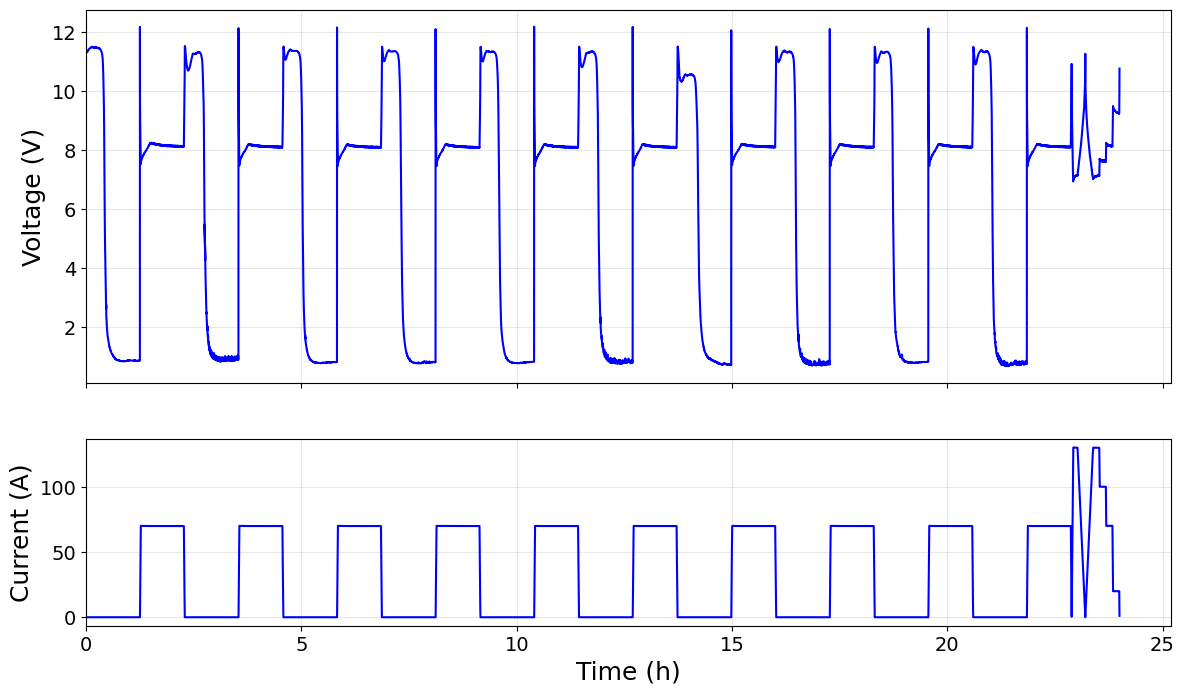

In [6]:
i=0
#plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
t = (Df4.loc[Df4.index.get_level_values(0).unique()[i]]["tpstot(ms)"] - Df4.loc[Df4.index.get_level_values(0).unique()[i]]["tpstot(ms)"].iloc[0]) / (1000*60*60)
ax[0].plot (t, Df4.loc[Df4.index.get_level_values(0).unique()[i]]["Upile"],color='blue')
ax[0].set_ylabel("Voltage (V)", size=18)
#ax[0].set_title("Test Case 2", size=18)
ax[1].plot(t, Df4.loc[Df4.index.get_level_values(0).unique()[i]]["Courant"], color='blue')
ax[1].set_ylabel("Current (A)", size=18)
ax[1].set_xlabel("Time (h)", size=18)
ax[0].tick_params(axis='both', colors='black', labelsize=14)
ax[1].tick_params(axis='both', colors='black', labelsize=14)
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)
ax[0].set_xlim(left=0)
ax[1].set_xlim(left=0)
#plt.savefig("Alice_sig2.pdf", format='pdf', bbox_inches='tight')
#plt.savefig( "Alice_sig2.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_sig2.eps", format='eps', bbox_inches='tight')
plt.show()
plt.style.use("default")

## Data Resampling

To reduce computational cost and accelerate model training, the raw time-series data is resampled every 30 seconds. This preprocessing step decreases the number of samples while preserving the overall system dynamics and trends.

In [7]:
def DfResampling(df, simpTime):
    Df=df.copy()
    Df = Df.reset_index()
    Df = Df.drop(columns=["level_1"])
    Df['tpstot(ms)'] = pd.to_datetime(Df['tpstot(ms)'], unit='ms')
    Df = Df.set_index('tpstot(ms)')
    
    num_cols = Df.select_dtypes(include='number').columns
    str_cols = Df.select_dtypes(include='object').columns
    Df = Df.resample(simpTime).agg({
        **{c: 'mean' for c in num_cols},
        **{c: 'first' for c in str_cols}})

    Df=Df.reset_index()
    Df['tpstot(ms)'] = Df['tpstot(ms)'].view('int64') / 1_000_000
    Df['step'] = Df.groupby('level_0').cumcount()
    Df = Df.set_index(['level_0', 'step'])
    return Df

NDf4 = DfResampling(Df4, '30s')
NDf4

C:\Users\abraydi\AppData\Local\Temp\ipykernel_26120\1304514803.py:15: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  Df['tpstot(ms)'] = Df['tpstot(ms)'].view('int64') / 1_000_000


tpstot(ms)       TeH2       TsH2  \
level_0                         step                                       
BQR_PM200_1stst_12102016_112336 0     1.372830e+09  22.040105  37.713421   
                                1     1.372860e+09  22.123800  37.236250   
                                2     1.372890e+09  22.197000  36.789100   
                                3     1.372920e+09  22.245000  36.341100   
                                4     1.372950e+09  22.282050  35.858500   
...                                            ...        ...        ...   
BQR_PM200_1stst_25102016_112342 2875  2.582310e+09  23.721300  35.704450   
                                2876  2.582340e+09  23.737800  35.375250   
                                2877  2.582370e+09  23.737800  34.997850   
                                2878  2.582400e+09  23.761700  34.635800   
                                2879  2.582430e+09  23.768800  34.445400   

                                          TeAIR      TsAIR      TeEAU  \
level_0                         step                                    
BQR_PM200_1stst_12102016_112336 0     20.704263  46.014947  53.590895   
                                1     20.763000  45.369650  53.318900   
                                2     20.817400  44.754900  53.042300   
                                3     20.876250  44.134650  52.776900   
                                4     20.925150  43.538600  52.517900   
...                                         ...        ...        ...   
BQR_PM200_1stst_25102016_112342 2875  22.492100  44.532650  53.506650   
                                2876  22.484300  44.392000  53.412150   
                                2877  22.478150  44.267500  53.322950   
                                2878  22.472700  44.096400  53.237600   
                                2879  22.467200  43.997600  53.185000   

                                          TsEAU        PeAir       PsAir  \
level_0                         step                                       
BQR_PM200_1stst_12102016_112336 0     53.076895   967.643053  971.862947   
                                1     52.802700   967.656300  971.830800   
                                2     52.534600   967.586250  971.838400   
                                3     52.279250   967.639250  971.808000   
                                4     52.041600   967.643000  971.825100   
...                                         ...          ...         ...   
BQR_PM200_1stst_25102016_112342 2875  53.096500  1009.900600  997.063150   
                                2876  53.011250  1009.932750  997.195900   
                                2877  52.921150  1010.200250  997.349550   
                                2878  52.827600  1010.704600  997.630350   
                                2879  52.499200  1013.057600  999.415200   

                                             PeH2         PsH2      DeH2  \
level_0                         step                                       
BQR_PM200_1stst_12102016_112336 0      993.472632   989.977632 -0.039684   
                                1      988.779850   985.281700 -0.039700   
                                2      983.884550   980.432650 -0.039600   
                                3      979.067150   975.619650 -0.039600   
                                4      974.476300   971.023100 -0.039900   
...                                           ...          ...       ...   
BQR_PM200_1stst_25102016_112342 2875  1040.889850  1024.174900  4.406850   
                                2876  1040.905000  1025.135550  4.403700   
                                2877  1040.474750  1023.326250  4.406700   
                                2878  1041.375100  1023.685000  4.407600   
                                2879  1045.886000  1026.933600  4.409400   

                                         DsH2     DeAir     DsAir   Courant  \
level_0                         step        

## Preprocessing Comparison (One Day)

Comparison of the original and resampled signals for a representative one-day period, showing that the 30-second resampling preserves the overall signal behavior while reducing the number of samples.

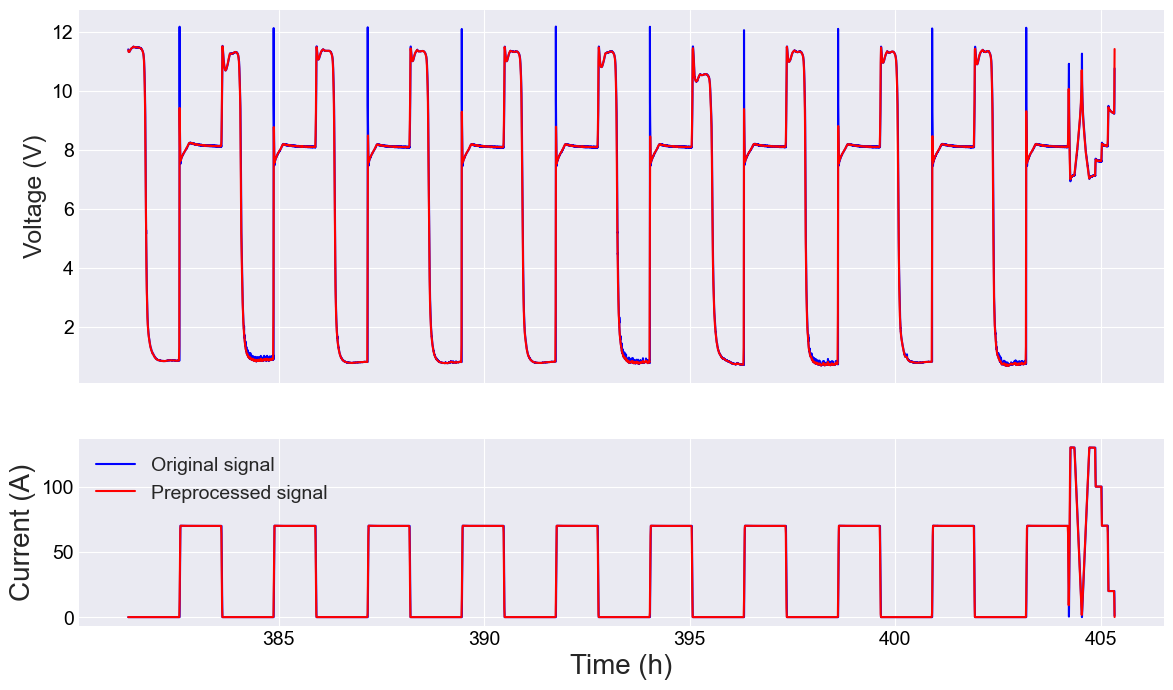

In [8]:
i=0
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (Df4.loc[Df4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), Df4.loc[Df4.index.get_level_values(0).unique()[i]]["Upile"],color='blue', label='Original signal')
ax[0].plot (NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["Upile"],color='red', label='Preprocessed signal')
ax[0].set_ylabel("Voltage (V)", size=18)
#ax[0].set_title("Test Case 2", size=18)
ax[1].plot(Df4.loc[Df4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), Df4.loc[Df4.index.get_level_values(0).unique()[i]]["Courant"], color='blue', label='Original signal')
ax[1].plot(NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["Courant"], color='red', label='Preprocessed signal')
ax[1].set_ylabel("Current (A)", size=20)
ax[1].set_xlabel("Time (h)", size=20)
ax[0].tick_params(axis='both', colors='black', labelsize=14)
ax[1].tick_params(axis='both', colors='black', labelsize=14)
ax[1].legend(fontsize=14)
#plt.savefig("ALICE_2_Preprocessing.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("ALICE_2_Preprocessing.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
plt.style.use("default")

## Global Signal Overview

Visualize the original and resampled voltage and current signals over the entire dataset.

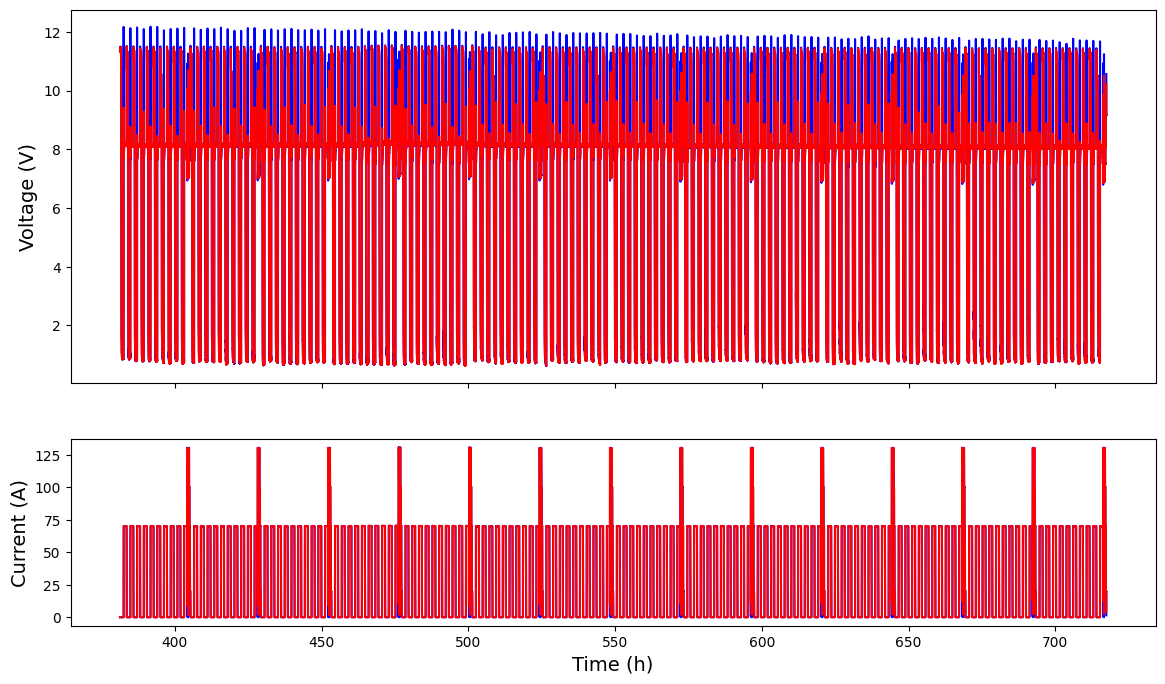

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (Df4["tpstot(ms)"]/(1000*60*60), Df4["Upile"],color='blue')
ax[0].plot (NDf4["tpstot(ms)"]/(1000*60*60), NDf4["Upile"],color='red')
ax[0].set_ylabel("Voltage (V)", size=14)
ax[1].plot(Df4["tpstot(ms)"]/(1000*60*60), Df4["Courant"], color='blue')
ax[1].plot(NDf4["tpstot(ms)"]/(1000*60*60), NDf4["Courant"], color='red')
ax[1].set_ylabel("Current (A)", size=14)
ax[1].set_xlabel("Time (h)", size=14)
plt.show()

## Train-Test Split

Split the dataset into training (70%) and testing (30%) subsets while preserving the temporal order of the measurements.

In [10]:
Trate = 0.7

Train = NDf4.iloc[0:int(len(NDf4)*Trate)]

Test = NDf4.iloc[int(len(NDf4)*Trate):]

print(len(Train), len(Test))
X_tr = Train.drop(columns=["Upile"]).values
Y_tr = Train ["Upile"].values.reshape(-1, 1)

X_ts = Test.drop(columns=["Upile"]).values
Y_ts = Test ["Upile"].values.reshape(-1, 1)

28224 12097


## Data Normalization

Normalize the input features and target variable using Min-Max scaling. The scalers are fitted on the training set and then applied to the test set to avoid data leakage.

The normalized inputs are finally reshaped into the format required by the deep learning models.

In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_tr_scaled = scaler_x.fit_transform(X_tr)
X_ts_scaled = scaler_x.transform(X_ts)

Ytr = scaler_y.fit_transform(Y_tr)
Yts = scaler_y.transform(Y_ts)

Xtr = X_tr_scaled.reshape(X_tr_scaled.shape[0], 1, 17)
Xts= X_ts_scaled.reshape(X_ts_scaled.shape[0], 1, 17)

## LSTM-self-attention Model

Hybrid architecture combining LSTM layers and self-attention for voltage prediction.

In [12]:
import torch.nn as nn

class LSTM_TF(nn.Module):
    def __init__(self, input_dim, seq_len):
        super(LSTM_TF, self).__init__()

        self.seq_len = seq_len

        # ----- Step 1: LSTM block -----
        self.lstm1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            batch_first=True,
            num_layers=1
        )

        self.lstm2 = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True,
            num_layers=1
        )

        # ----- Step 2: Multi-head self-attention -----
        # PyTorch MHA uses "embed_dim" = num_heads * head_dim
        embed_dim = 64  # 32*8
        self.attention_proj = nn.Linear(input_dim, embed_dim)

        self.mha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=4,
            dropout=0,
            batch_first=True
        )

        # Concatenated dimension =  256 + 192
        self.post_cat_dim = 64 + embed_dim 

        # ----- Step 3–4: Dense layers -----
        self.fc1 = nn.Linear(self.post_cat_dim, 64)
        self.dropout = nn.Dropout(0.3)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)

        # ----- LSTM block -----
        x1, _ = self.lstm1(x)  # (B, L, 256)
        x1, _ = self.lstm2(x1) # (B, L, 256)

        # ----- Transformer block -----
        attn_input = self.attention_proj(x)  # (B, L, 192)
        attn_output, _ = self.mha(attn_input, attn_input, attn_input)

        # Concatenate features along last axis
        x_cat = torch.cat([x1, attn_output], dim=-1)  # (B, L, 448)

        # Flatten
        x_pool = torch.mean(x_cat, dim=1)

        # Dense layers
        x_dense = torch.relu(self.fc1(x_pool))
        x_dense = self.dropout(x_dense)

        return self.out(x_dense)

In [13]:
# Model Summary
seq_len  = Xtr.shape[1]
input_dim = Xtr.shape[2]

model = LSTM_TF(input_dim=input_dim, seq_len=seq_len)
print(model)

from torchinfo import summary
summary(model, input_size=(1, seq_len, input_dim))

LSTM_TF(
  (lstm1): LSTM(17, 64, batch_first=True)
  (lstm2): LSTM(64, 64, batch_first=True)
  (attention_proj): Linear(in_features=17, out_features=64, bias=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LSTM_TF                                  [1, 1]                    --
├─LSTM: 1-1                              [1, 1, 64]                21,248
├─LSTM: 1-2                              [1, 1, 64]                33,280
├─Linear: 1-3                            [1, 1, 64]                1,152
├─MultiheadAttention: 1-4                [1, 1, 64]                16,640
├─Linear: 1-5                            [1, 64]                   8,256
├─Dropout: 1-6                           [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
Total params: 80,641
Trainable params: 80,641
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.06
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.26
Estimated Total Size (MB): 0.26

## Training Setup

Create PyTorch datasets and dataloaders, then define the loss function, optimizer, and learning rate scheduler.

In [14]:
from torch.utils.data import TensorDataset, DataLoader
Xtr_torch = torch.tensor(Xtr, dtype=torch.float32)
Ytr_torch = torch.tensor(Ytr, dtype=torch.float32)

Xts_torch = torch.tensor(Xts, dtype=torch.float32)
Yts_torch = torch.tensor(Yts, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(Xtr_torch, Ytr_torch)
test_dataset  = TensorDataset(Xts_torch, Yts_torch)

BATCH_SIZE= 32
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [15]:
criterion = torch.nn.L1Loss()  # MAE: L1
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# LR scheduler equivalent to ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=4,
    min_lr=1e-6
)

## Model Training

Train the LSTM-self-attention model and monitor the training and validation losses over multiple epochs.

In [16]:
device = torch.device("cuda")
model.to(device)

EPOCHS = 20
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- Validation -----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for Xv, yv in test_loader:
            Xv = Xv.to(device)
            yv = yv.to(device)

            pv = model(Xv)
            lv = criterion(pv, yv)

            val_loss += lv.item()

    val_loss /= len(test_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} — train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 1/20 — train_loss=0.1263 | val_loss=0.0537
Epoch 2/20 — train_loss=0.0712 | val_loss=0.0370
Epoch 3/20 — train_loss=0.0611 | val_loss=0.0281
Epoch 4/20 — train_loss=0.0596 | val_loss=0.0215
Epoch 5/20 — train_loss=0.0585 | val_loss=0.0364
Epoch 6/20 — train_loss=0.0573 | val_loss=0.0264
Epoch 7/20 — train_loss=0.0573 | val_loss=0.0265
Epoch 8/20 — train_loss=0.0569 | val_loss=0.0236
Epoch 9/20 — train_loss=0.0569 | val_loss=0.0526
Epoch 10/20 — train_loss=0.0540 | val_loss=0.0203
Epoch 11/20 — train_loss=0.0541 | val_loss=0.0187
Epoch 12/20 — train_loss=0.0542 | val_loss=0.0201
Epoch 13/20 — train_loss=0.0543 | val_loss=0.0195
Epoch 14/20 — train_loss=0.0537 | val_loss=0.0189
Epoch 15/20 — train_loss=0.0538 | val_loss=0.0201
Epoch 16/20 — train_loss=0.0535 | val_loss=0.0222
Epoch 17/20 — train_loss=0.0535 | val_loss=0.0224
Epoch 18/20 — train_loss=0.0540 | val_loss=0.0213
Epoch 19/20 — train_loss=0.0537 | val_loss=0.0229
Epoch 20/20 — train_loss=0.0533 | val_loss=0.0216


## Prediction Visualization

Generate model predictions, transform them back to the original voltage scale, and compare them with the experimental data.

In [17]:
def plot_pytorch(df, ln_tr, pred_train, pred_test, name="LSTM_CNN", save_name="name", title="title"):

    # ----- Plot -----
    plt.figure(figsize=(12, 5))

    # Experimental data
    plt.scatter(df["tpstot(ms)"]/(1000*60*60), df['Upile'], facecolors='none', edgecolors='blue', s=1, label='Experimental data')

    # Train predictions
    plt.plot( df[:ln_tr]["tpstot(ms)"]/(1000*60*60), pred_train, color='red', label=name + ' (Train)')

    # Test predictions
    plt.plot( df[ln_tr:]["tpstot(ms)"]/(1000*60*60), pred_test, color='green', label=name + ' (Test)')

    # Mark training region
    split_time = df["tpstot(ms)"].iloc[ln_tr]/(1000*60*60)
    plt.axvspan(df["tpstot(ms)"].iloc[0]/(1000*60*60), split_time, color='gray', alpha=0.1, label='Training region')

    plt.xlabel("Time (h)", fontsize=12)
    plt.ylabel("Voltage (V)", fontsize=12)
    plt.title("Fuel Cell Voltage Degradation – " + title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
#    plt.savefig(save_name + ".pdf", format='pdf', bbox_inches='tight')
    plt.show()

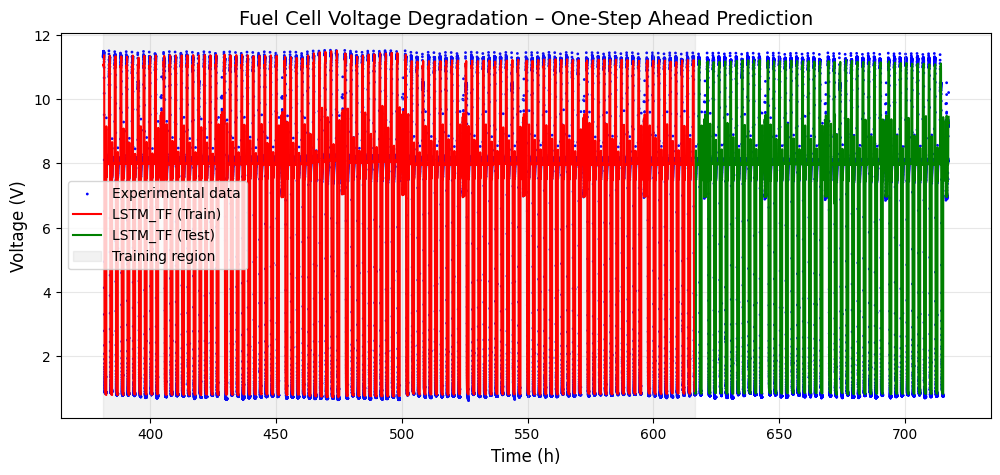

In [18]:
device = torch.device("cpu")
model = model.to(device)
model.eval()
Xtrain_torch = torch.tensor(Xtr, dtype=torch.float32).to(device)
Xtest_torch = torch.tensor(Xts, dtype=torch.float32).to(device)

with torch.no_grad():
    pred_train = model(Xtrain_torch).cpu().numpy()
    pred_test = model(Xtest_torch).cpu().numpy()

pred_train = scaler_y.inverse_transform(pred_train)
pred_test = scaler_y.inverse_transform(pred_test)

plot_pytorch( NDf4, len(Xtr), pred_train, pred_test, name="LSTM_TF", save_name="BZ100_1_LSTM_TF_1step",
              title="One-Step Ahead Prediction")

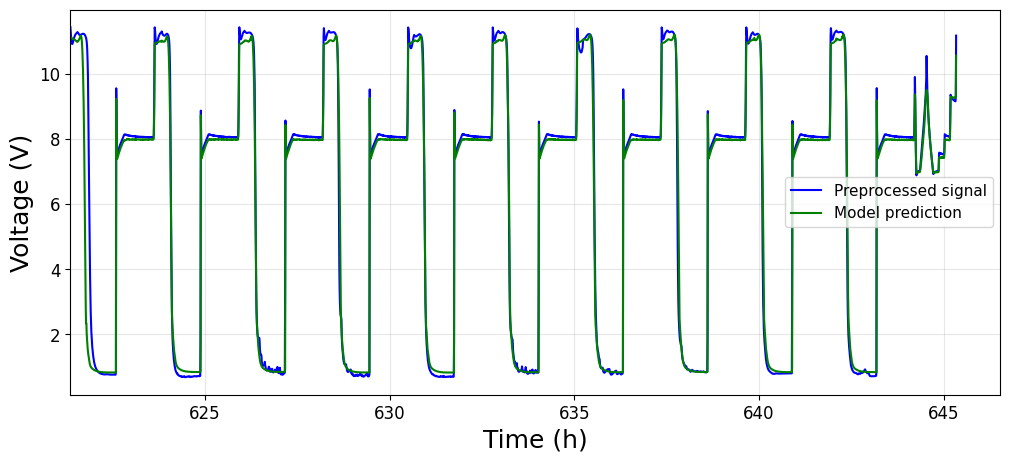

In [19]:
i=10
plt.figure(figsize=(12, 5))
plt.plot( NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60), NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]['Upile'], color='blue', label='Preprocessed signal')
plt.plot( NDf4[len(Xtr):][577:3457]["tpstot(ms)"]/(1000*60*60), pred_test[577:3457], color='green', label='Model prediction')
plt.xlabel("Time (h)", fontsize=18)
plt.ylabel("Voltage (V)", fontsize=18)
plt.tick_params(axis='both', colors='black', labelsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(left=(NDf4.loc[NDf4.index.get_level_values(0).unique()[i]]["tpstot(ms)"]/(1000*60*60)).iloc[0])
#plt.savefig("Alice_2_LSTMATTn_pred1c.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("Alice_2_LSTMATTn_pred1c.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("Alice_2_LSTMATTn_pred1c.eps", format='pdf', bbox_inches='tight')
plt.show()

## Model Evaluation

Evaluate the model performance on the training and test sets using MSE, RMSE, MAE, and R² metrics.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

y_train_true = NDf4[: len(Xtr)]['Upile']   # or whatever your true training target is
y_train_pred = pred_train

mse_tr, rmse_tr, mae_tr, r2_tr = regression_metrics(y_train_true, y_train_pred)

print("TRAINING METRICS")
print(f"MSE  : {mse_tr:.4f}")
print(f"RMSE : {rmse_tr:.4f}")
print(f"MAE  : {mae_tr:.4f}")
print(f"R²   : {r2_tr:.4f}")

TRAINING METRICS
MSE  : 0.6701
RMSE : 0.8186
MAE  : 0.2605
R²   : 0.9563


In [21]:
y_test_true = NDf4[len(Xtr):]['Upile']



mse_LT, rmse_LT, mae_LT, r2_LT = regression_metrics(y_test_true, pred_test)

print("\nLong term prediction")
print(f"MSE  : {mse_LT:.4f}")
print(f"RMSE : {rmse_LT:.4f}")
print(f"MAE  : {mae_LT:.4f}")
print(f"R²   : {r2_LT:.4f}")




Long term prediction
MSE  : 0.5754
RMSE : 0.7585
MAE  : 0.2340
R²   : 0.9612
